## Import libraries and data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv('/Users/williamdang/Documents/Weather/weather/Data/clean_seattle_portland_weather.csv')

df['date'] = pd.to_datetime(df['date']) #To convert data in "date" column from text to date format

df.head()

,date,city,precipitation
0,2018-01-01,SEA,0.0
1,2018-01-01,PWM,0.0
2,2018-01-02,SEA,0.0
3,2018-01-02,PWM,0.0
4,2018-01-03,SEA,0.0


## Precipitation over time
A line plot of daily precipitation for each city shows the overall pattern and any extreme days.

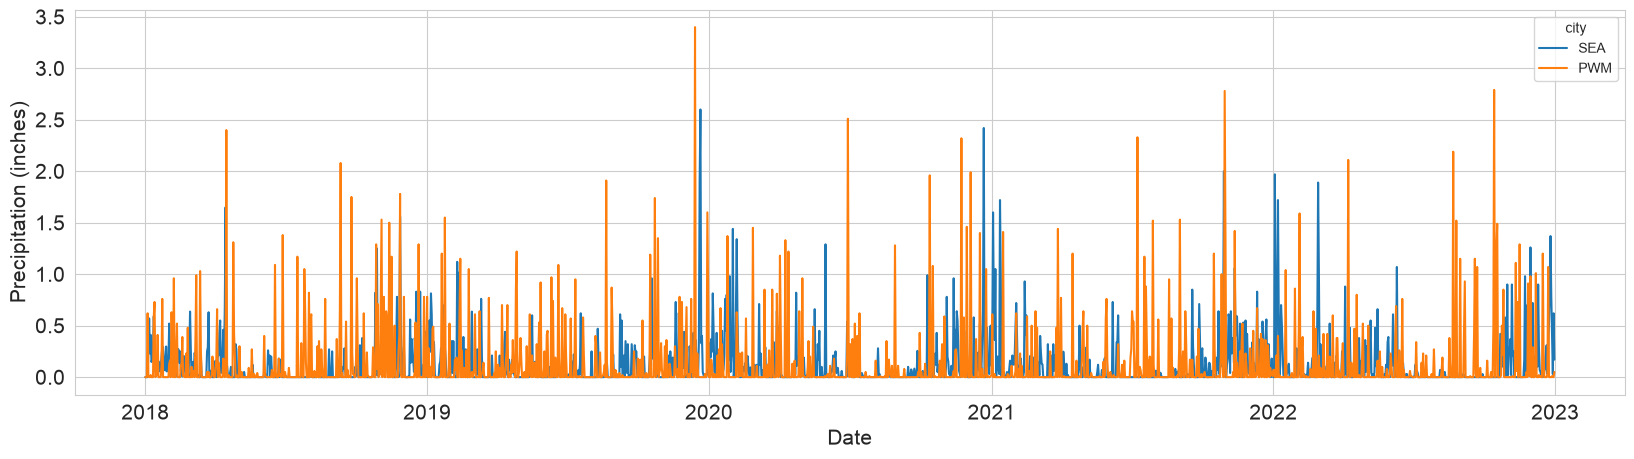

In [3]:
plt.figure(figsize=(20, 5))
sns.lineplot(data=df, x='date', y='precipitation', hue='city')

plt.xlabel('Date', fontsize = 15)
plt.ylabel('Precipitation (inches)',fontsize = 15)

plt.tick_params(labelsize = 15)
plt.show()

Both cities have many dry or nearly dry days, with occasional spikes. Seattle has a clear yearly cycle: wet winters and very dry summers. Portland's spikes are spread across the year and reach higher; the largest single day is 3.4 inches in Portland, compared with 2.6 inches in Seattle. With this many days, the lines overlap heavily, so the summaries below are easier to compare.

## Descriptive statistics
Use `groupby` and `describe` to summarize daily precipitation for each city.

In [4]:
df[['city','precipitation']].groupby('city').describe()

precipitation                                               
             count      mean       std  min  25%   50%   75%  max
city                                                             
PWM         1826.0  0.130482  0.336819  0.0  0.0  0.00  0.05  3.4
SEA         1826.0  0.113350  0.240541  0.0  0.0  0.01  0.12  2.6

Portland has a slightly higher mean (0.130 in/day) than Seattle (0.113 in/day), and a larger standard deviation (0.34 vs. 0.24). That means Portland's precipitation varies more from day to day. The medians tell the opposite story: Portland's median is 0.00 and Seattle's is 0.01, so more than half of Portland's days are completely dry. Seattle's 75th percentile (0.12) is also higher than Portland's (0.05). In short, Seattle gets frequent light rain, and Portland gets fewer but heavier storms.

## Mean daily precipitation by city
A bar plot compares the average daily precipitation in the two cities.

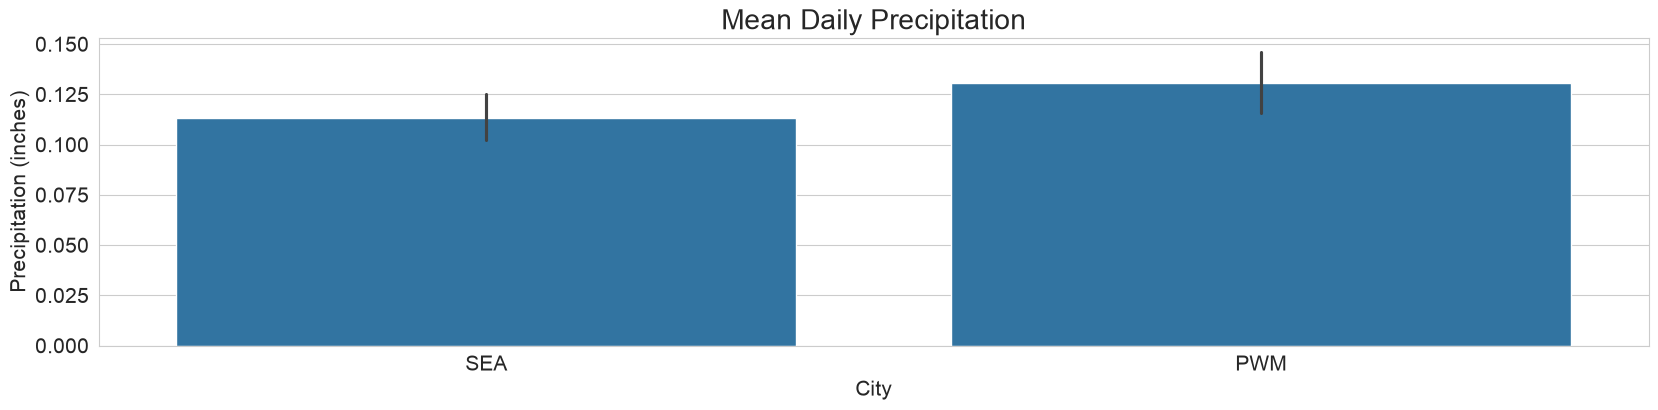

In [5]:
plt.figure(figsize =(20,4))

sns.barplot(data=df, x='city', y='precipitation')
plt.xlabel('City', fontsize = 15)
plt.ylabel('Precipitation (inches)',fontsize = 15)
plt.title('Mean Daily Precipitation', fontsize = 20)

plt.tick_params(labelsize = 15)
plt.show()

Portland's bar is a little taller than Seattle's, which matches the means from `describe`. The black lines on top of each bar are error bars. The next section explains what they mean.

## What do the error bars mean?
Check the Seaborn documentation for `barplot` to see what the error bars represent.

In [6]:
sns.barplot 

<function seaborn.categorical.barplot(data=None, *, x=None, y=None, hue=None, order=None, hue_order=None, estimator='mean', errorbar=('ci', 95), n_boot=1000, seed=None, units=None, weights=None, orient=None, color=None, palette=None, saturation=0.75, fill=True, hue_norm=None, width=0.8, dodge='auto', gap=0, log_scale=None, native_scale=False, formatter=None, legend='auto', capsize=0, err_kws=None, ci=<deprecated>, errcolor=<deprecated>, errwidth=<deprecated>, ax=None, **kwargs)>

By default, Seaborn uses `errorbar=('ci', 95)`. That draws a 95% confidence interval for the mean, estimated by bootstrapping (resampling the data many times). The error bars show how precisely the mean is estimated, not how spread out the daily values are.

## Add a month column
Extract the month from each date so the data can be grouped by season.

In [7]:
df['month']= pd.DatetimeIndex(df['date']).month
df.head()

,date,city,precipitation,month
0,2018-01-01,SEA,0.0,1
1,2018-01-01,PWM,0.0,1
2,2018-01-02,SEA,0.0,1
3,2018-01-02,PWM,0.0,1
4,2018-01-03,SEA,0.0,1


The new `month` column holds values from 1 (January) to 12 (December). We'll use it to compare the seasonal patterns of the two cities.

## Box plot of precipitation by month
A box plot shows the distribution of daily precipitation for each month and city: the median, the quartiles, and outliers.

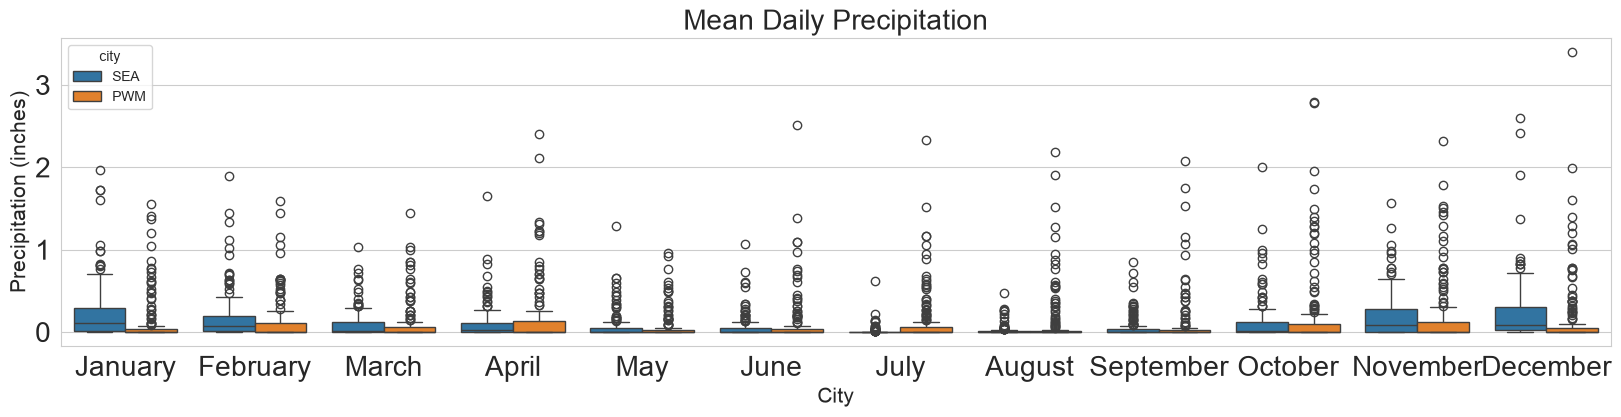

In [8]:
plt.figure(figsize =(20,4))

sns.boxplot(data=df, x='month', y='precipitation',hue='city')
plt.xlabel('City', fontsize = 15)
plt.ylabel('Precipitation (inches)',fontsize = 15)
plt.title('Mean Daily Precipitation', fontsize = 20)

plt.tick_params(labelsize = 20)

# get month names and set them as the x-axis tick labels
import calendar
month_names= list(calendar.month_name[1:]) # Get month names

plt.xticks(ticks=range(12), labels=month_names) # To set x-axis to month names

plt.show()

This plot is hard to read. Most daily values are near zero, so the boxes are squashed at the bottom, and a few large storms stretch the y-axis up to 3.4 inches. Almost every point above the boxes is drawn as an outlier, which makes the boxes themselves hard to see.

## Adjust the box plot's orientation and axis limits
Flip the plot horizontal so the months read down the side, and limit the precipitation axis to 0–1 inch to zoom in on the boxes.

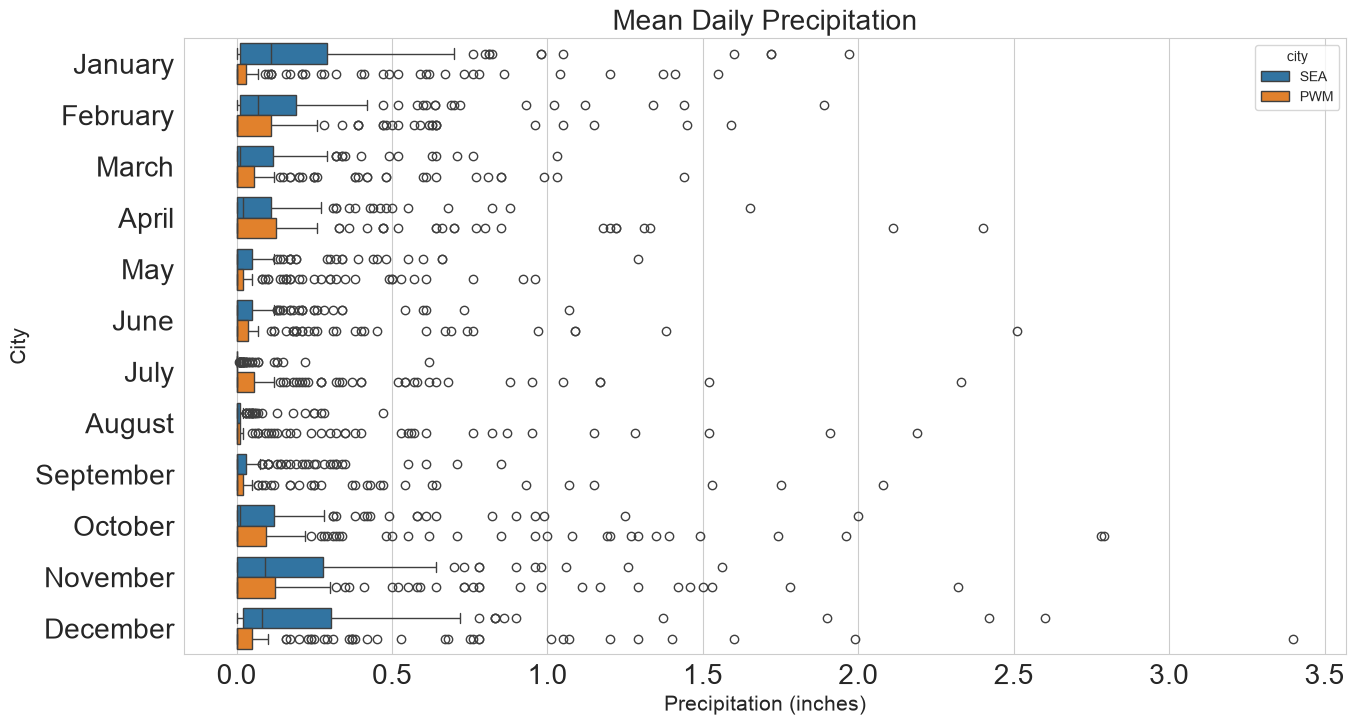

In [9]:
plt.figure(figsize =(15,8))

sns.boxplot(data=df, x='precipitation', y='month',hue='city',orient= 'h')
plt.ylabel('City', fontsize = 15)
plt.xlabel('Precipitation (inches)',fontsize = 15)
plt.title('Mean Daily Precipitation', fontsize = 20)

plt.tick_params(labelsize = 20)


plt.yticks(ticks=range(12), labels=month_names) # To set y-axis to month names

plt.show()

The seasonal change is evident. From November to February, Seattle's boxes are wide, but in July and August, they are nearly empty. Portland's boxes are little every month because the majority of the days are dry. Its rain appears as outliers distributed rather evenly throughout the year. Limiting the axis obscures the greatest storms; therefore this approach is best for comparing average days rather than extremes.

## Mean precipitation by month
A bar plot of mean daily precipitation for each month compares the seasonal cycle of the two cities.

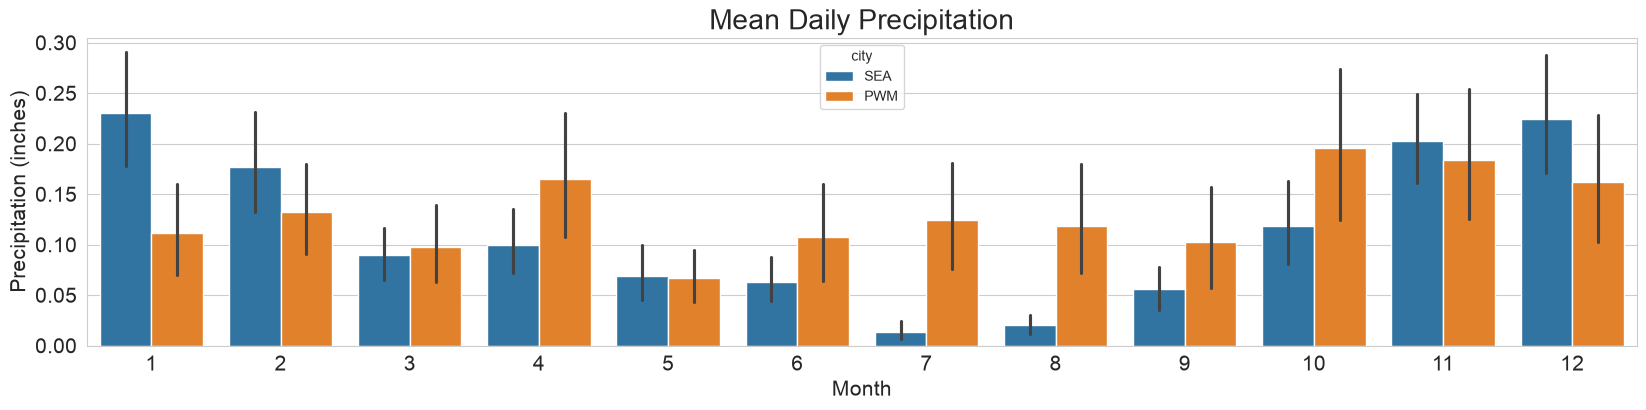

In [10]:
plt.figure(figsize =(20,4))

sns.barplot(data=df, x='month', y='precipitation',hue='city')
plt.xlabel('Month', fontsize = 15)
plt.ylabel('Precipitation (inches)',fontsize = 15)
plt.title('Mean Daily Precipitation', fontsize = 20)

plt.tick_params(labelsize = 15)
plt.show()

Seattle shows a strong U shape: the highest means are in December and January and the lowest in July and August. Portland is much flatter. It is wetter than Seattle from April through October, and Seattle is wetter from November through February.

## Mean precipitation by city and month
Use `groupby` to get the exact values behind the bar plot.

In [11]:
df[['month','precipitation','city']].groupby(['city','month']).mean() 

precipitation
city month               
PWM  1           0.111935
     2           0.132624
     3           0.097871
     4           0.164533
     5           0.067226
     6           0.107400
     7           0.124065
     8           0.118065
     9           0.102400
     10          0.195226
     11          0.183933
     12          0.161871
SEA  1           0.230742
     2           0.176472
     3           0.089914
     4           0.099667
     5           0.069161
     6           0.063217
     7           0.013919
     8           0.020129
     9           0.055622
     10          0.118452
     11          0.202667
     12          0.224903

The table confirms the plot. Seattle's mean falls from 0.231 in/day in January to 0.014 in July, a more than 16-fold decrease. Portland's year-round temperature ranges from 0.067 (May) to 0.195 (October). The wettest month in Portland is October, whereas Seattle's wettest months are January and December.


## Add a column for days with any precipitation
Create a True/False column showing whether any precipitation fell that day. This measures how *often* it rains, separately from how *much*.

In [12]:
df['any_precipitation']= df['precipitation']>0
df.head()

,date,city,precipitation,month,any_precipitation
0,2018-01-01,SEA,0.0,1,False
1,2018-01-01,PWM,0.0,1,False
2,2018-01-02,SEA,0.0,1,False
3,2018-01-02,PWM,0.0,1,False
4,2018-01-03,SEA,0.0,1,False


`any_precipitation` is `True` on any day with measurable precipitation. Because True counts as 1 and False as 0, the mean of this column is the proportion of days with precipitation. 

## Proportion of days with any precipitation
Calculate the proportion overall and by month, and plot the monthly values.

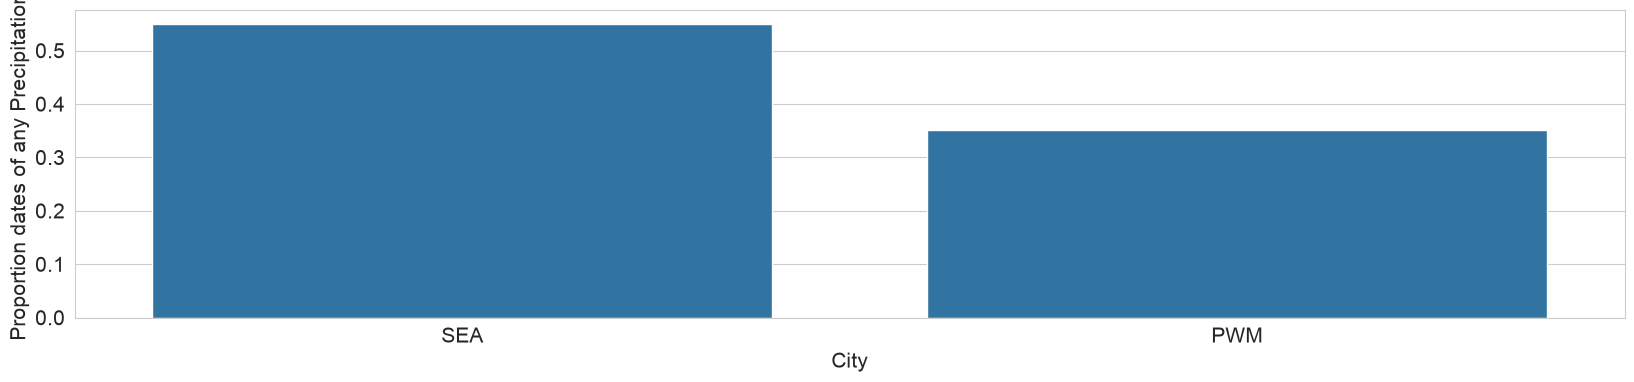

In [13]:
plt.figure(figsize =(20,4))

sns.barplot(data=df, x='city', y='any_precipitation',errorbar = None)
plt.xlabel('City', fontsize = 15)
plt.ylabel('Proportion dates of any Precipitation ',fontsize = 15)

plt.tick_params(labelsize = 15)
plt.show()

Seattle actually sees precipitation far more often than Portland—dripping on about 55% of days compared to Portland's 35%—even though Portland collects more total rain overall. During December and February, Seattle gets wet weather on more than four out of five days. In fact, Portland only out-rains Seattle during the summer dry spell in July and August. Otherwise, Portland’s rainy-day rate stays relatively steady throughout the year, hovering between 26% and 41% each month.

A quick note on the data: Seattle’s missing weather entries were filled in using monthly averages, which are rarely absolute zero. That slightly skews Seattle’s overall rate upward. If you look strictly at the days with recorded measurements, Seattle’s frequency drops to about 51%—though the main takeaway stays the same.

### How much does it rain on rainy days?
Look only at days with precipitation to compare the typical size of a rain event.

In [14]:
df[df['any_precipitation']].groupby('city')['precipitation'].describe()

,count,mean,std,min,25%,50%,75%,max
city,,,,,,,,
PWM,640.0,0.372281,0.483579,0.0100,0.0475,0.18,0.52,3.4
SEA,1003.0,0.206358,0.293550,0.0025,0.0300,0.10,0.26,2.6


When it actually rains, Portland gets hit nearly twice as hard as Seattle. On wet days, Portland sees a median of 0.18 inches compared to Seattle’s 0.10, with an average (mean) of 0.37 inches versus 0.21. Seattle’s rainfall is overwhelmingly made up of constant drizzles and tiny daily amounts, whereas Portland experiences much heavier downpours that stretch out its overall totals.

### Heavy precipitation days
Count the days with at least 1 inch of precipitation, and find the heaviest rainy day in each city.

In [15]:
df['year'] = pd.DatetimeIndex(df['date']).year
df['heavy_rain'] = df['precipitation'] > 1

In [16]:
heavy_per_year = df.groupby(['city', 'year', 'month'])['heavy_rain'].sum().reset_index()

`heavy_per_year` has one row for each year, month, and city (5 years × 12 months × 2 cities = 120 rows). Each row holds the number of heavy-rain days in that month. Summing the True/False column counts the True values. Months with no heavy rain still appear with a count of 0. This matters for the next step: if the zeros were dropped, the averages would be too high.

### Average number of heavy-rain days per month
Average the yearly counts across 2018–2022 to find how many heavy-rain days each city typically gets in each month of the year.

In [17]:
avg_heavy = heavy_per_year.groupby(['month', 'city'])['heavy_rain'].mean()
avg_heavy

month  city
1      PWM     1.0
       SEA     1.0
2      PWM     0.8
       SEA     1.0
3      PWM     0.4
       SEA     0.2
4      PWM     1.6
       SEA     0.2
5      PWM     0.0
       SEA     0.2
6      PWM     0.8
       SEA     0.2
7      PWM     1.0
       SEA     0.0
8      PWM     1.0
       SEA     0.0
9      PWM     1.0
       SEA     0.0
10     PWM     2.4
       SEA     0.4
11     PWM     1.8
       SEA     0.6
12     PWM     1.8
       SEA     0.8
Name: heavy_rain, dtype: float64

- Portland sees downpours almost year-round, peaking in fall (October averages 2.4 days; November and December average 1.8). May was its only month with zero heavy rain across all five years.

- Seattle tops out at just 1 heavy-rain day per month (January and February), with none at all from July through September. It only edges out Portland in February (1.0 vs. 0.8 days) and ties in January and May.

This confirms the pattern: Portland gets its high volume from heavy storms, while Seattle relies on steady, lighter drizzle.

### Plot of heavy-rain days by month
A bar plot of `heavy_per_year` compares the seasonal pattern of heavy rain in the two cities. Each bar is the mean number of heavy-rain days across the five years. The error bars are Seaborn's default 95% confidence interval for that mean.

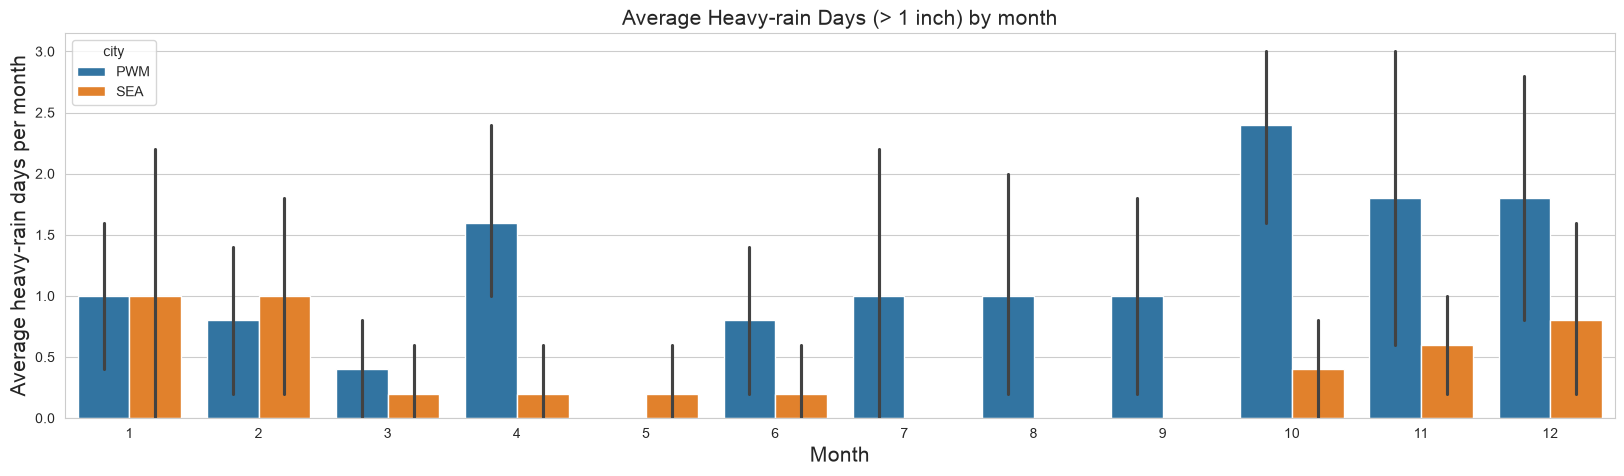

In [18]:
plt.figure(figsize=(20, 5))

sns.barplot(data=heavy_per_year, x='month', y='heavy_rain', hue='city')
plt.xlabel('Month',fontsize=15)
plt.ylabel('Average heavy-rain days per month',fontsize=15)
plt.title('Average Heavy-rain Days (> 1 inch) by month',fontsize=15)

plt.show()

The chart mirrors the data: Portland sees heavy rain almost year-round—peaking from October to December—while Seattle’s is brief, winter-bound, and nonexistent from July through September.

Small five-year sample sizes create wide, overlapping error bars, making exact monthly comparisons uncertain. However, the overall trend is clear: Portland consistently gets more heavy-rain days, particularly in summer and fall.

### Share of annual precipitation by season
Group the months into seasons and calculate what percentage of each city's total precipitation falls in each season.

In [19]:
season_of_month = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Fall', 10: 'Fall', 11: 'Fall'
}
df['season'] = df['month'].map(season_of_month)

# Calculate total per city and season
seasonal_total = df.groupby(['city', 'season'])['precipitation'].sum()
city_total = df.groupby('city')['precipitation'].sum()

# Compute percentages and unstack 'season' into columns
seasonal_percent = (seasonal_total / city_total * 100).round(1).unstack(level='season')

# Reorder columns explicitly to standard seasonal order
seasons = ['Winter', 'Spring', 'Summer', 'Fall']
seasonal_percent = seasonal_percent.reindex(columns=seasons).fillna(0)

seasonal_percent

season,Winter,Spring,Summer,Fall
city,,,,
PWM,25.7,21.1,22.5,30.7
SEA,46.1,19.1,7.1,27.6


In [20]:
# Create a plot to visualize the precipitation by season

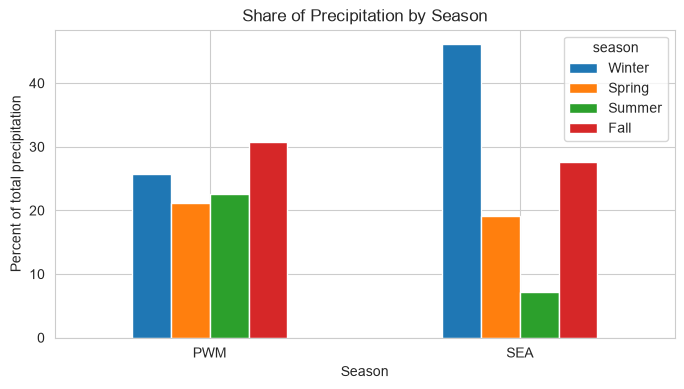

In [21]:
seasonal_percent.plot(kind='bar', figsize=(8, 4), rot=0)
plt.xlabel('Season')
plt.ylabel('Percent of total precipitation')
plt.title('Share of Precipitation by Season')
plt.show()

Almost half of Seattle's precipitation falls in winter, and only 7% falls in summer. Portland's precipitation is close to evenly split, with each season getting between 21% and 31%. Fall is Portland's wettest season.

# Perform statistical test for mean precipitation by each month

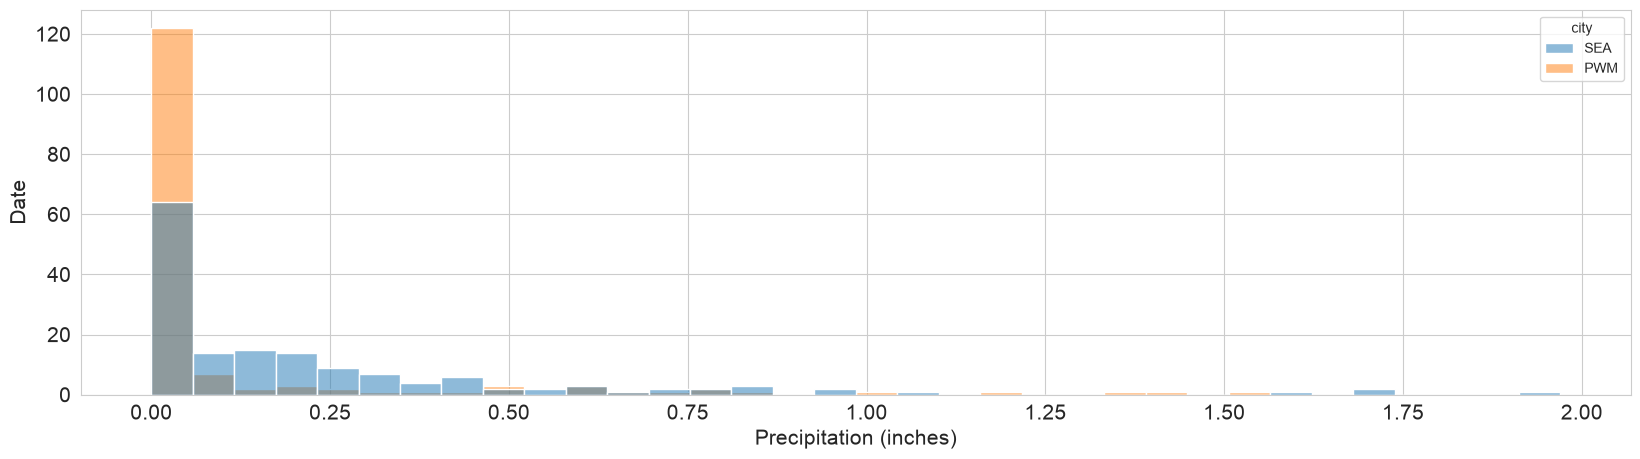

In [22]:
plt.figure(figsize=(20, 5))
sns.histplot(data=df.loc[df['month']==1], x='precipitation', hue='city')
plt.xlabel('Precipitation (inches)', fontsize = 15)
plt.ylabel('Date',fontsize = 15)
plt.tick_params(labelsize = 15)
plt.show()

# Import libraries

In [23]:
from scipy import stats

### Are the monthly differences significant?
For each month, a t-test checks whether Seattle and Portland have different mean daily precipitation. If the p-value is below 0.05, the difference is significant. `equal_var=False` runs Welch's t-test, which doesn't assume the two cities have the same variance.

In [24]:
significance_level = 0.05
significantly_different = np.zeros(12)

# Perform t-test for each month
for month in range(1,13):
        # Get precipitation date from Seattle and Portland, ME for the current month
        sea_data= df.loc[(df['city'] == 'SEA') & (df['month']==month),'precipitation']
        portland_data= df.loc[(df['city'] == 'PWM') & (df['month']==month),'precipitation']

        t_statistic, p_value = stats.ttest_ind(sea_data,portland_data, equal_var = False)

        if p_value < significance_level:
            significantly_different[month-1]=1

        print(f"month {month}:")
        print(f"  t-statistic={t_statistic:.2f}")
        print(f"  p-value t test = {p_value:.3f}")
        print("-"*20)

month 1:
  t-statistic=3.33
  p-value t test = 0.001
--------------------
month 2:
  t-statistic=1.27
  p-value t test = 0.203
--------------------
month 3:
  t-statistic=-0.35
  p-value t test = 0.728
--------------------
month 4:
  t-statistic=-1.85
  p-value t test = 0.066
--------------------
month 5:
  t-statistic=0.10
  p-value t test = 0.918
--------------------
month 6:
  t-statistic=-1.61
  p-value t test = 0.109
--------------------
month 7:
  t-statistic=-4.32
  p-value t test = 0.000
--------------------
month 8:
  t-statistic=-3.60
  p-value t test = 0.000
--------------------
month 9:
  t-statistic=-1.71
  p-value t test = 0.089
--------------------
month 10:
  t-statistic=-1.76
  p-value t test = 0.080
--------------------
month 11:
  t-statistic=0.47
  p-value t test = 0.640
--------------------
month 12:
  t-statistic=1.38
  p-value t test = 0.168
--------------------


Only 3 of the 12 months show statistically significant differences:

- January: Seattle is wetter (p = 0.001).

- July & August: Portland is wetter (p < 0.001), as Seattle goes almost bone-dry in midsummer.

The other nine months show no significant difference. Even after adjusting for multiple testing with a stricter threshold (p < 0.004), these three months easily hold up.

### Mean precipitation by month, with significant months marked
This bar plot compares mean daily precipitation for each month and adds a mark above the months where the t-test found a significant difference.

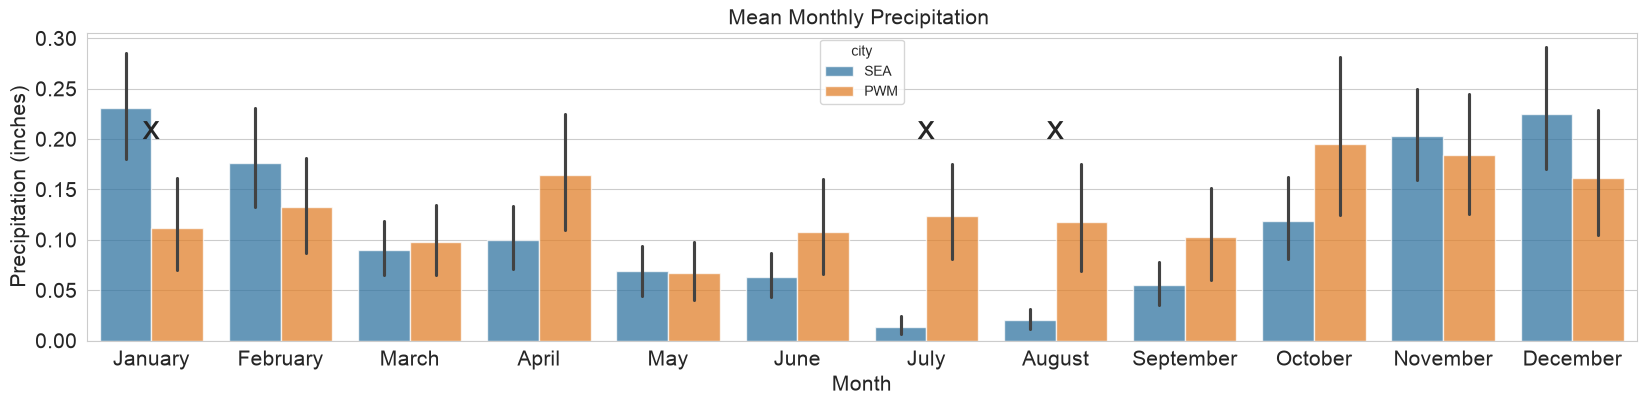

In [25]:
plt.figure(figsize =(20,4))
sns.barplot(data=df, x='month', y='precipitation',hue ='city', alpha= 0.75)
plt.xlabel('Month', fontsize = 15)
plt.ylabel('Precipitation (inches)',fontsize = 15)
plt.title('Mean Monthly Precipitation ',fontsize = 15)

plt.tick_params(labelsize = 15)
plt.xticks(ticks=range(12), labels=month_names)

# Add star for significantly different months:
for month in range(12):
    if significantly_different[month]==1:
        # Add a star
        plt.text(month,0.2,'x', ha='center', fontsize=25)
plt.show()


The marks appear above January, July, and August, the three months with a significant difference. In January, Seattle's bar is clearly taller. In July and August, Seattle's bar almost disappears while Portland's stays at its usual level. In the other months, the bars are closer and their error bars overlap, which matches the t-test results.

### Is the proportion of rainy days significantly different?
For each month, a two-proportion z-test checks whether Seattle and Portland have a different share of days with any precipitation. A crosstab counts the rainy and dry days for each city. If the p-value is below 0.05, the difference is significant.

In [26]:
from statsmodels.stats.proportion import proportions_ztest

significance_level = 0.05
significantly_different_proportion= np.zeros(12)

#Perform t-test for each month
for month in range (1,13):

        #Create a contingency table for Seattle and Portland, ME for curent month:
        contingency_table = pd.crosstab(
            df.loc[df['month'] ==month,'city'], df.loc[df['month']==month, 'any_precipitation']
        )

        # Calculate the number of True values (days with precipitation) for each city
        days_with_precipitation = contingency_table [True]

        # Calculate the total number of days for each city
        total_counts = contingency_table.sum(axis=1)

        # Hypothesis test
        zstat, p_value = proportions_ztest(
            count = days_with_precipitation, nobs = total_counts, alternative = 'two-sided'
        )

        if p_value < significance_level:
            significantly_different_proportion[month-1]=1

        print(f"month {month}:")
        print(f"  t-statistic={t_statistic:.2f}")
        print(f"  p-value t test = {p_value:.3f}")
        print("-"*20)


month 1:
  t-statistic=1.38
  p-value t test = 0.000
--------------------
month 2:
  t-statistic=1.38
  p-value t test = 0.000
--------------------
month 3:
  t-statistic=1.38
  p-value t test = 0.003
--------------------
month 4:
  t-statistic=1.38
  p-value t test = 0.001
--------------------
month 5:
  t-statistic=1.38
  p-value t test = 0.005
--------------------
month 6:
  t-statistic=1.38
  p-value t test = 0.126
--------------------
month 7:
  t-statistic=1.38
  p-value t test = 0.060
--------------------
month 8:
  t-statistic=1.38
  p-value t test = 0.703
--------------------
month 9:
  t-statistic=1.38
  p-value t test = 0.144
--------------------
month 10:
  t-statistic=1.38
  p-value t test = 0.009
--------------------
month 11:
  t-statistic=1.38
  p-value t test = 0.000
--------------------
month 12:
  t-statistic=1.38
  p-value t test = 0.000
--------------------


8 of 12 months (Jan–May and Oct–Dec) show significant differences, with Seattle having a far higher share of rainy days—especially in winter (e.g., Dec: 83% vs. 39%, p < 0.001). Summer (June–Sept) levels out, with both cities seeing similar rain frequency.

This flips the earlier t-test on its head: Seattle gets rain much more often, but it's usually light drizzle—yielding higher rainfall volume only in January.

### Contingency table for January
Before running the z-test for every month, look at the January contingency table. It counts, for each city, how many January days had precipitation (`True`) and how many were dry (`False`).

In [27]:
contingency_table = pd.crosstab(
    df.loc[df['month'] == 1,'city'], df.loc[df['month']==1,'any_precipitation']
)
contingency_table

any_precipitation,False,True
city,,
PWM,106,49
SEA,36,119


Each city has 155 January days (31 days × 5 years). Portland was dry on most of them, with precipitation on 49 days (32%). Seattle is the reverse: it had precipitation on 119 days (77%). The z-test uses the `True` column as the number of rainy days and the row totals as the number of days.
Keep going in Claude Code

# Calculate the number of True values (days with precipitation) for each city

In [28]:
days_with_precipitation =contingency_table[True]
days_with_precipitation

city
PWM     49
SEA    119
Name: True, dtype: int64

Portland had precipitation on 49 January days, and Seattle had it on 119.

# Calculate the total number of days for each city

In [29]:
total_counts = contingency_table.sum(axis=1)
total_counts

city
PWM    155
SEA    155
dtype: int64

Each city has 155 January days (31 days × 5 years). These totals and the counts above are the inputs to the z-test.

# Hypothesis test

### Z-test for January
A two-proportion z-test checks whether the share of rainy days in January is different between the two cities. If the p-value is below 0.05, the difference is significant.

In [30]:
zstat, p_value =proportions_ztest(
        count=days_with_precipitation,
        nobs=total_counts,
        alternative='two-sided'
)

print(zstat)
print(p_value)

-7.979580748396986
1.468311634157918e-15


The z-statistic is about −7.98, and the p-value is about 1.5 × 10⁻¹⁵, far below 0.05. The difference is significant: it rained on 77% of Seattle's January days and only 32% of Portland's. The z-statistic is negative because Portland is listed first in the table and has the lower proportion.

#### Plot the proportion of days with any precipitation each month with a star  for significant differences

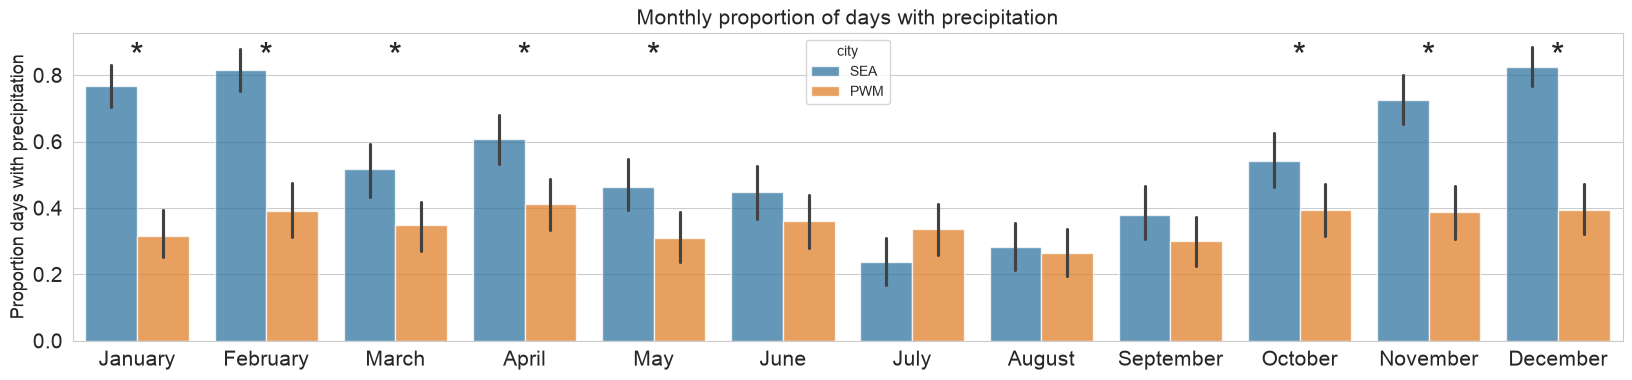

In [31]:
plt.figure(figsize=(20,4))

sns.barplot(data=df, x='month', y='any_precipitation', hue='city',alpha=0.75)

plt.xlabel(None)
plt.ylabel('Proportion days with precipitation', fontsize=13)
plt.title('Monthly proportion of days with precipitation', fontsize=15)

plt.tick_params(labelsize=15)
plt.xticks(ticks=range(12), labels=month_names)

# Add stars for significantly different months
for month in range(12):
    if significantly_different_proportion[month] ==1:

        # Add a star
        plt.text(month, 0.825, '*', ha='center', fontsize=25)

plt.show()

Stars appear on 8 months: January–May and October–December. In all of them, Seattle has rain on more days than Portland. The gap is biggest in winter, when Seattle has rain on about 80% of days. From June to September there are no stars, because Seattle's summer dry season brings its rainy-day share down to about Portland's level.